# Universe Selection — Finding the Best 15 Tickers

Four criteria that make a ticker worth including:

| Criterion | Proxy metric | Why it matters |
|---|---|---|
| **Liquidity** | Median daily volume | Can execute trades; more training rows |
| **Volatility** | Std of daily log returns | More BUY/SELL signals; HOLD-heavy models hurt flat names |
| **Intraday movement** | Mean \|close - open\| / open | Captures the daily range your signals need to be right about |
| **Sentiment coverage** | % of recent days with news | Sentiment feature actually populates |

We score each ticker on all four, combine into a composite score, and pick the top 15.

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

OHLCV_DIR   = Path('../data/raw/ohlcv')
SENT_DIR    = Path('../data/raw/sentiment')
LOOKBACK    = 252   # trading days (~1 year) used for scoring
TOP_N       = 15
CONF_THRESH = 0.60  # minimum confidence for ranked buy/sell signals later

print('Tickers available:', len(list(OHLCV_DIR.iterdir())))

Tickers available: 84


## 1. Load OHLCV for all tickers

In [2]:
frames = []
for ticker_dir in sorted(OHLCV_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    csvs = sorted(ticker_dir.glob('*.csv'))
    if not csvs:
        continue
    df = pd.read_csv(csvs[-1], parse_dates=['date'])
    frames.append(df)

all_df = pd.concat(frames, ignore_index=True)
all_df = all_df.sort_values(['ticker', 'date'])

# Keep only the most recent LOOKBACK trading days
max_date = all_df['date'].max()
recent   = all_df.groupby('ticker').tail(LOOKBACK).copy()

print(f'Date range: {all_df["date"].min().date()} → {max_date.date()}')
print(f'Tickers loaded: {recent["ticker"].nunique()}')
recent.head(3)

Date range: 2024-04-23 → 2026-04-24
Tickers loaded: 83


,ticker,date,open,high,low,close,volume,vwap
249,AAL,2025-04-23,9.82,10.03,9.310,9.32,102486905,9.5537
250,AAL,2025-04-24,9.41,9.68,9.210,9.61,70563299,9.5067
251,AAL,2025-04-25,9.59,9.84,9.495,9.75,65137090,9.6859


In [18]:
recent.shape

(19176, 8)

## 2. Compute per-ticker metrics

In [19]:
def compute_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['log_return']      = np.log(df['close'] / df['close'].shift(1))
    df['intraday_move']   = (df['close'] - df['open']).abs() / df['open']
    df['daily_range']     = (df['high'] - df['low']) / df['open']
    return df

recent = recent.groupby('ticker', group_keys=False).apply(compute_metrics)

metrics = (
    recent
    .groupby('ticker')
    .agg(
        trading_days   = ('date', 'count'),
        median_volume  = ('volume', 'median'),
        return_std     = ('log_return', 'std'),
        mean_intraday  = ('intraday_move', 'mean'),
        mean_range     = ('daily_range', 'mean'),
        mean_close     = ('close', 'mean'),
    )
    .reset_index()
)

# Annualised volatility
metrics['ann_vol'] = metrics['return_std'] * np.sqrt(252)

metrics.sort_values('median_volume', ascending=False).head(10)

,ticker,trading_days,median_volume,return_std,mean_intraday,mean_range,mean_close,ann_vol
50,NVDA,252,174078554.5,0.021086,0.013484,0.027340,173.221984,0.334726
77,TSLL,252,117760393.0,0.061236,0.038369,0.075123,15.382857,0.972086
5,ALP,2,112735425.0,NaN,0.172564,0.373688,0.255000,NaN
74,TQQQ,252,109950185.5,0.030544,0.019328,0.037853,47.163681,0.484876
66,SOXL,252,89580711.0,0.060304,0.034129,0.069143,40.584246,0.957302
32,INTC,252,87306030.5,0.041521,0.023544,0.044908,34.873452,0.659123
56,PLUG,252,87305562.0,0.068562,0.045866,0.091191,1.986733,1.088382
53,OPEN,252,81960619.0,0.094468,0.055157,0.107039,4.565670,1.499629
75,TSLA,252,78283504.5,0.030487,0.019297,0.037922,383.627599,0.483963
69,SPY,252,72684305.0,0.007997,0.004922,0.009812,651.033294,0.126944


## 3. Sentiment coverage — how often does news data exist?

In [20]:
sent_coverage = {}
for ticker_dir in sorted(SENT_DIR.iterdir()):
    if not ticker_dir.is_dir():
        continue
    ticker = ticker_dir.name
    files  = list(ticker_dir.glob('*.csv'))
    if not files:
        sent_coverage[ticker] = {'total_files': 0, 'with_data': 0, 'coverage_pct': 0.0}
        continue
    with_data = 0
    for f in files:
        try:
            df = pd.read_csv(f)
            if not df.empty and df['company_news_score'].notna().any():
                with_data += 1
        except Exception:
            pass
    sent_coverage[ticker] = {
        'total_files': len(files),
        'with_data':   with_data,
        'coverage_pct': (with_data / len(files) * 100) if files else 0.0,
    }

sent_df = pd.DataFrame.from_dict(sent_coverage, orient='index').reset_index()
sent_df.columns = ['ticker', 'sentiment_files', 'sentiment_with_data', 'sentiment_coverage_pct']
sent_df.sort_values('sentiment_coverage_pct', ascending=False).head(10)

,ticker,sentiment_files,sentiment_with_data,sentiment_coverage_pct
22,ENVB,1,1,100.000000
81,WU,1,1,100.000000
37,LNAI,1,1,100.000000
54,PAPL,2,2,100.000000
62,SCNI,2,2,100.000000
63,SMCI,1,1,100.000000
73,TLRY,1,1,100.000000
50,NVDA,3,2,66.666667
32,INTC,3,2,66.666667
46,NOK,3,2,66.666667


## 4. Composite score — combine all four criteria

In [21]:
def minmax(s: pd.Series) -> pd.Series:
    rng = s.max() - s.min()
    return (s - s.min()) / rng if rng > 0 else s * 0

scored = metrics.merge(sent_df[['ticker', 'sentiment_coverage_pct']], on='ticker', how='left')
scored['sentiment_coverage_pct'] = scored['sentiment_coverage_pct'].fillna(0)

# Normalise each criterion to [0, 1]
scored['s_volume']    = minmax(np.log1p(scored['median_volume']))
scored['s_vol']       = minmax(scored['ann_vol'])
scored['s_intraday']  = minmax(scored['mean_intraday'])
scored['s_sentiment'] = minmax(scored['sentiment_coverage_pct'])

# Weights — adjust these to favour what matters most to you
W_VOLUME    = 0.30
W_VOLATILITY = 0.35
W_INTRADAY  = 0.25
W_SENTIMENT = 0.10

scored['composite'] = (
    W_VOLUME    * scored['s_volume'] +
    W_VOLATILITY * scored['s_vol'] +
    W_INTRADAY  * scored['s_intraday'] +
    W_SENTIMENT * scored['s_sentiment']
)

scored = scored.sort_values('composite', ascending=False).reset_index(drop=True)
scored[['ticker', 'median_volume', 'ann_vol', 'mean_intraday',
        'sentiment_coverage_pct', 'composite']].head(20)

,ticker,median_volume,ann_vol,mean_intraday,sentiment_coverage_pct,composite
0,ILLR,339902.5,3.226931,1.248863,0.000000,0.605066
1,PAPL,72996.5,4.140135,0.063878,100.000000,0.490555
2,BMNR,39533406.0,2.681723,0.062334,0.000000,0.447507
3,GPUS,14438578.0,2.457356,0.067909,0.000000,0.408528
4,SMCI,29464504.0,0.797607,0.025863,100.000000,0.405563
5,BMNU,42133837.0,1.991361,0.070556,0.000000,0.404079
6,NVTS,20957188.5,1.529569,0.044107,50.000000,0.400264
7,ELPW,949.5,5.305621,0.208385,0.000000,0.390893
8,LNAI,302249.5,2.129294,0.068714,100.000000,0.390800
9,INTC,87306030.5,0.659123,0.023544,66.666667,0.389295


## 5. Visualise — who ranks where on each criterion?

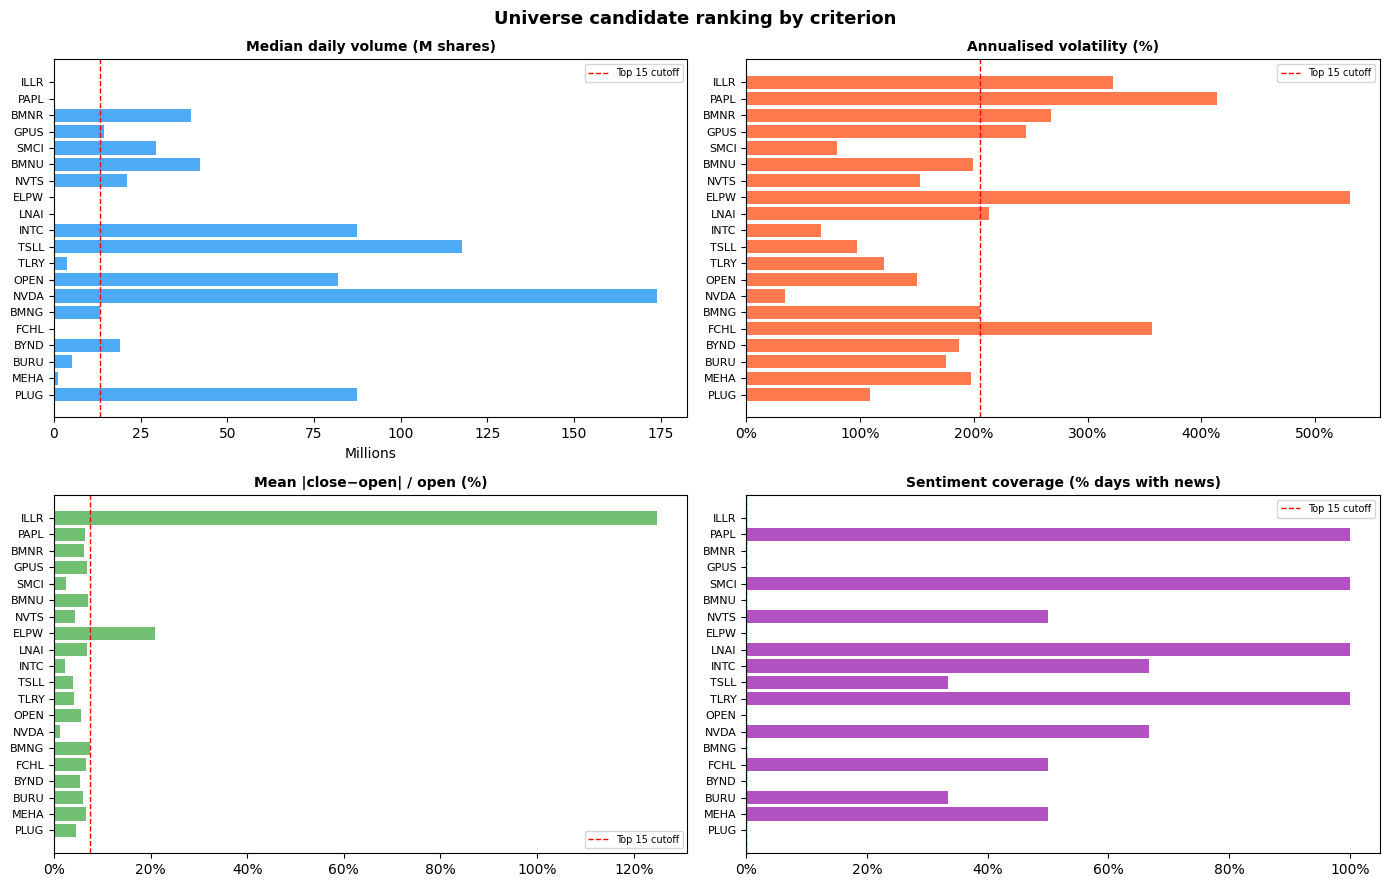

In [22]:
top20 = scored.head(20).copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Universe candidate ranking by criterion', fontsize=13, fontweight='bold')

def hbar(ax, series, labels, title, fmt=None, color='#4C72B0'):
    y = range(len(labels))
    bars = ax.barh(y, series, color=color, alpha=0.8)
    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.axvline(series.iloc[TOP_N - 1], color='red', linestyle='--', linewidth=1, label=f'Top {TOP_N} cutoff')
    ax.legend(fontsize=7)
    if fmt:
        ax.xaxis.set_major_formatter(fmt)

labels = top20['ticker'].tolist()

hbar(axes[0,0], top20['median_volume'] / 1e6, labels,
     'Median daily volume (M shares)', color='#2196F3')
axes[0,0].set_xlabel('Millions')

hbar(axes[0,1], top20['ann_vol'] * 100, labels,
     'Annualised volatility (%)', color='#FF5722')
axes[0,1].xaxis.set_major_formatter(mtick.PercentFormatter())

hbar(axes[1,0], top20['mean_intraday'] * 100, labels,
     'Mean |close−open| / open (%)', color='#4CAF50')
axes[1,0].xaxis.set_major_formatter(mtick.PercentFormatter())

hbar(axes[1,1], top20['sentiment_coverage_pct'], labels,
     'Sentiment coverage (% days with news)', color='#9C27B0')
axes[1,1].xaxis.set_major_formatter(mtick.PercentFormatter())

plt.tight_layout()
plt.show()

## 6. Composite score chart — the recommended top 15

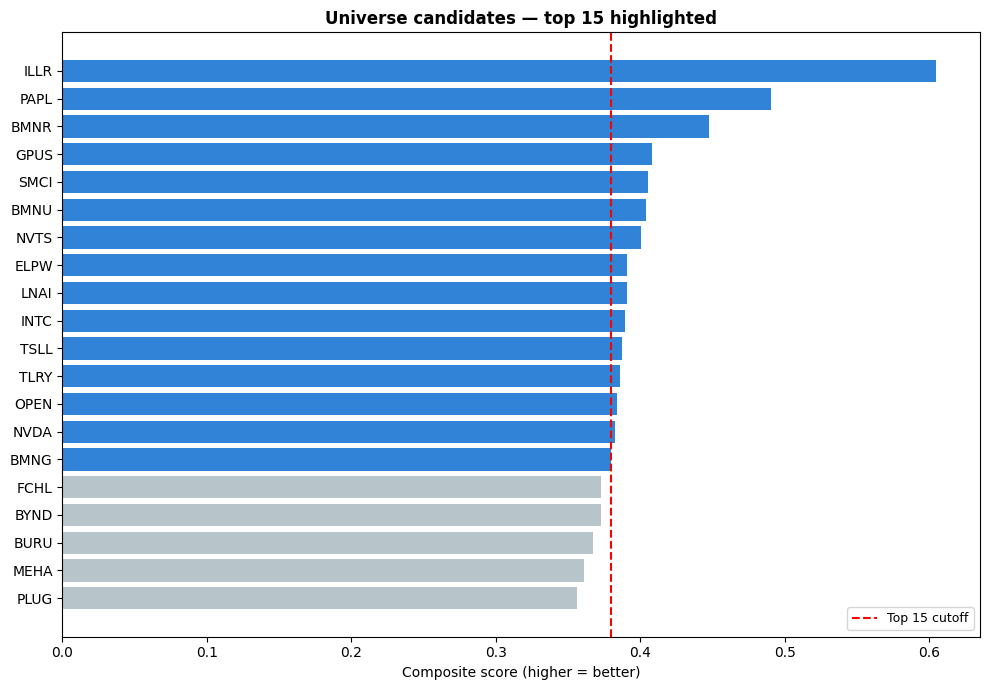


Recommended universe (15 tickers):
['ILLR', 'PAPL', 'BMNR', 'GPUS', 'SMCI', 'BMNU', 'NVTS', 'ELPW', 'LNAI', 'INTC', 'TSLL', 'TLRY', 'OPEN', 'NVDA', 'BMNG']


In [23]:
fig, ax = plt.subplots(figsize=(10, 7))

colors = ['#1976D2' if i < TOP_N else '#B0BEC5' for i in range(len(top20))]
bars = ax.barh(top20['ticker'][::-1], top20['composite'][::-1], color=colors[::-1], alpha=0.9)

cutoff_score = scored.iloc[TOP_N - 1]['composite']
ax.axvline(cutoff_score, color='red', linestyle='--', linewidth=1.5, label=f'Top {TOP_N} cutoff')

ax.set_xlabel('Composite score (higher = better)', fontsize=10)
ax.set_title(f'Universe candidates — top {TOP_N} highlighted', fontsize=12, fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

selected = scored.head(TOP_N)['ticker'].tolist()
print(f'\nRecommended universe ({TOP_N} tickers):')
print(selected)

## 7. Intraday movement distribution — are signals achievable?

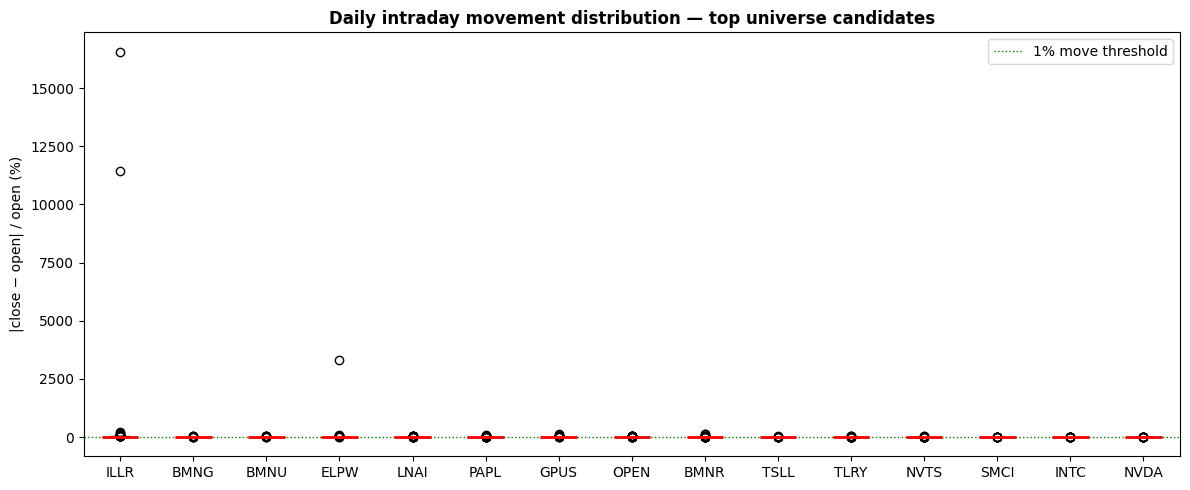

In [24]:
top_tickers = scored.head(TOP_N)['ticker'].tolist()
top_data = recent[recent['ticker'].isin(top_tickers)].copy()

fig, ax = plt.subplots(figsize=(12, 5))

order = (
    top_data.groupby('ticker')['intraday_move']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

data_by_ticker = [top_data[top_data['ticker'] == t]['intraday_move'].dropna() * 100
                  for t in order]

bp = ax.boxplot(data_by_ticker, labels=order, patch_artist=True,
                medianprops=dict(color='red', linewidth=2))
for patch in bp['boxes']:
    patch.set_facecolor('#90CAF9')
    patch.set_alpha(0.7)

ax.set_ylabel('|close − open| / open (%)')
ax.set_title('Daily intraday movement distribution — top universe candidates', fontweight='bold')
ax.axhline(1.0, color='green', linestyle=':', linewidth=1, label='1% move threshold')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Correlation matrix — avoid a universe that all moves together

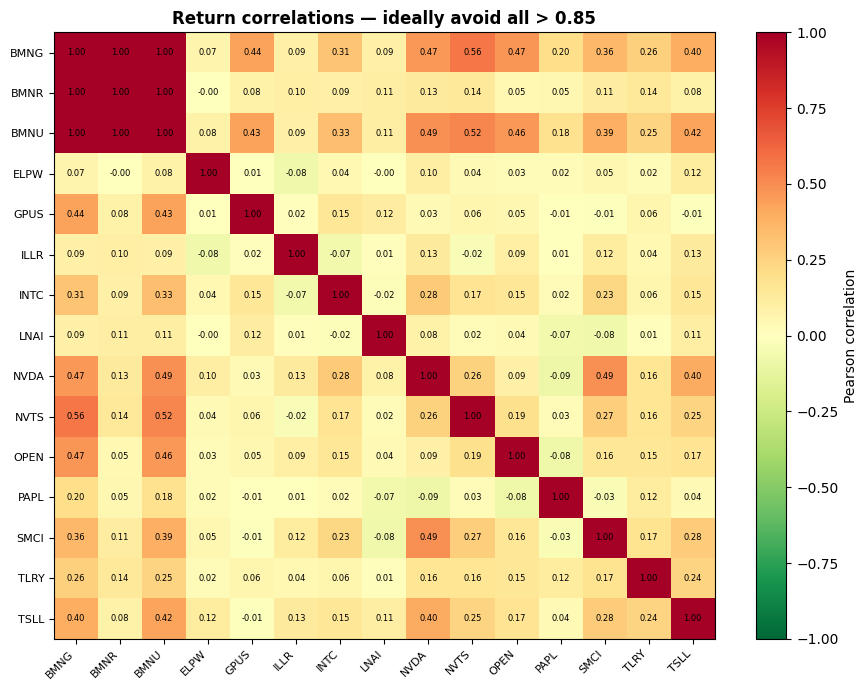

Highly correlated pairs (>0.85) — consider swapping one:
  BMNG / BMNU: 0.999
  BMNG / BMNR: 0.998
  BMNR / BMNU: 0.997


In [25]:
returns_pivot = (
    recent[recent['ticker'].isin(top_tickers)]
    .pivot(index='date', columns='ticker', values='log_return')
    .dropna(how='all')
)

corr = returns_pivot.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap='RdYlGn_r', vmin=-1, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson correlation')

tickers_ordered = corr.columns.tolist()
ax.set_xticks(range(len(tickers_ordered)))
ax.set_yticks(range(len(tickers_ordered)))
ax.set_xticklabels(tickers_ordered, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(tickers_ordered, fontsize=8)

for i in range(len(tickers_ordered)):
    for j in range(len(tickers_ordered)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=6)

ax.set_title('Return correlations — ideally avoid all > 0.85', fontweight='bold')
plt.tight_layout()
plt.show()

# Flag highly correlated pairs
high_corr = [
    (corr.columns[i], corr.columns[j], corr.iloc[i, j])
    for i in range(len(corr))
    for j in range(i+1, len(corr))
    if abs(corr.iloc[i, j]) > 0.85
]
if high_corr:
    print('Highly correlated pairs (>0.85) — consider swapping one:')
    for a, b, c in sorted(high_corr, key=lambda x: -abs(x[2])):
        print(f'  {a} / {b}: {c:.3f}')
else:
    print('No pairs above 0.85 — good diversity.')

## 9. Summary table — final recommended universe

In [26]:
summary = scored.head(TOP_N)[[
    'ticker', 'median_volume', 'ann_vol', 'mean_intraday',
    'mean_close', 'sentiment_coverage_pct', 'composite'
]].copy()

summary.columns = [
    'Ticker', 'Median Vol (shares)', 'Ann. Vol (%)', '|C−O|/O (%)',
    'Mean Close ($)', 'Sentiment Coverage (%)', 'Composite Score'
]
summary['Ann. Vol (%)']        = (summary['Ann. Vol (%)'] * 100).round(1)
summary['|C−O|/O (%)']         = (summary['|C−O|/O (%)'] * 100).round(2)
summary['Mean Close ($)']      = summary['Mean Close ($)'].round(2)
summary['Sentiment Coverage (%)'] = summary['Sentiment Coverage (%)'].round(1)
summary['Composite Score']     = summary['Composite Score'].round(3)
summary['Median Vol (shares)'] = summary['Median Vol (shares)'].apply(lambda x: f'{x:,.0f}')

summary = summary.reset_index(drop=True)
summary.index += 1
display(summary)

print('\n--- Copy this into configs/ingestion.yaml ---')
print('fixed_universe:')
for t in summary['Ticker'].tolist():
    print(f'  - {t}')

,Ticker,Median Vol (shares),Ann. Vol (%),|C−O|/O (%),Mean Close ($),Sentiment Coverage (%),Composite Score
1,ILLR,"339,902",322.7,124.89,0.55,0.0,0.605
2,PAPL,"72,996",414.0,6.39,2.22,100.0,0.491
3,BMNR,"39,533,406",268.2,6.23,31.60,0.0,0.448
4,GPUS,"14,438,578",245.7,6.79,1.09,0.0,0.409
5,SMCI,"29,464,504",79.8,2.59,39.02,100.0,0.406
6,BMNU,"42,133,837",199.1,7.06,8.90,0.0,0.404
7,NVTS,"20,957,188",153.0,4.41,8.00,50.0,0.400
8,ELPW,950,530.6,20.84,1307.73,0.0,0.391
9,LNAI,"302,250",212.9,6.87,0.81,100.0,0.391
10,INTC,"87,306,030",65.9,2.35,34.87,66.7,0.389



--- Copy this into configs/ingestion.yaml ---
fixed_universe:
  - ILLR
  - PAPL
  - BMNR
  - GPUS
  - SMCI
  - BMNU
  - NVTS
  - ELPW
  - LNAI
  - INTC
  - TSLL
  - TLRY
  - OPEN
  - NVDA
  - BMNG


## 10. Weight sensitivity — does changing weights change the top 15?

Try different weight combinations and see which tickers are **always** in the top 15 regardless of weights — those are the safest picks.

In [27]:
import itertools

weight_sets = [
    (0.40, 0.30, 0.20, 0.10),  # volume-heavy
    (0.20, 0.50, 0.20, 0.10),  # volatility-heavy
    (0.25, 0.25, 0.40, 0.10),  # intraday-heavy
    (0.20, 0.30, 0.30, 0.20),  # sentiment-boosted
    (0.30, 0.35, 0.25, 0.10),  # baseline (matches above)
]

membership = {t: 0 for t in scored['ticker']}
for wv, wvol, wi, ws in weight_sets:
    scored['tmp'] = wv * scored['s_volume'] + wvol * scored['s_vol'] + wi * scored['s_intraday'] + ws * scored['s_sentiment']
    top = scored.nlargest(TOP_N, 'tmp')['ticker'].tolist()
    for t in top:
        membership[t] += 1

scored.drop(columns=['tmp'], inplace=True)

stability = pd.Series(membership).sort_values(ascending=False)
always_in  = stability[stability == len(weight_sets)].index.tolist()
sometimes  = stability[(stability > 0) & (stability < len(weight_sets))].index.tolist()

print(f'Always in top {TOP_N} across all weight sets ({len(always_in)} tickers):')
print(' ', always_in)
print(f'\nSometimes in top {TOP_N} ({len(sometimes)} tickers — borderline):')
print(' ', sometimes)

Always in top 15 across all weight sets (5 tickers):
  ['ILLR', 'BMNR', 'NVTS', 'PAPL', 'TLRY']

Sometimes in top 15 (19 tickers — borderline):
  ['NVDA', 'GPUS', 'SMCI', 'BMNU', 'ELPW', 'LNAI', 'INTC', 'BMNG', 'TSLL', 'OPEN', 'FCHL', 'AIXI', 'MEHA', 'CHSN', 'WU', 'ENVB', 'BYND', 'PLUG', 'BURU']
